Импорты, seed и устройство

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import time

import json
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device: cpu
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


Загрузка датасета EMNIST и определение transform

In [51]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


dataset_train = datasets.EMNIST(root='./data',
                          train=True,
                          download=True,
                          transform=transforms.ToTensor(),
                          split="balanced")
dataset_test = datasets.EMNIST(root='./data',
                          train=False,
                          download=True,
                          transform=transforms.ToTensor(),
                          split="balanced")

Разбиение train/val из train-части с фиксированным seed

In [52]:
train_ratio = 0.8
train_size = int(train_ratio * len(dataset_train))
val_size = len(dataset_train) - train_size

generator = torch.Generator().manual_seed(SEED)
dataset_train, dataset_val = random_split(
    dataset_train,
    [train_size, val_size],
    generator=generator
)

Создать DataLoader для train/val/test

In [53]:
batch_size = 64

train_loader = DataLoader(
    dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    dataset_val,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    dataset_test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [54]:
x_batch, y_batch = next(iter(train_loader))

print(f"Количество батчей: {len(train_loader)}")
print(f"Размер батча: {x_batch.shape[0]}")
print(f"Shape images: {x_batch.shape}")
print(f"Shape labels: {y_batch.shape}")
print(f"Тип данных images: {x_batch.dtype}")
print(f"Тип данных labels: {y_batch.dtype}")
print(f"Уникальные метки в батче: {torch.unique(y_batch).tolist()}")
print(f"images min value: {x_batch.min():.4f}")
print(f"images max value: {x_batch.max():.4f}")
print(f"images mean value: {x_batch.mean():.4f}")
print(f"images std value: {x_batch.std():.4f}")

Количество батчей: 1410
Размер батча: 64
Shape images: torch.Size([64, 1, 28, 28])
Shape labels: torch.Size([64])
Тип данных images: torch.float32
Тип данных labels: torch.int64
Уникальные метки в батче: [0, 2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 17, 18, 19, 23, 24, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 46]
images min value: 0.0000
images max value: 1.0000
images mean value: 0.1919
images std value: 0.3483


Класс MLP

In [55]:
class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_sizes=[512, 256, 128], activation = "relu", num_classes=47, dropout_rate=0.0, use_batchnorm=False):
        super(MLP, self).__init__()

        layers = [nn.Flatten()]

        prev_size = input_size

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
                layers.append(act_layer())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
                
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))

        self.network = nn.Sequential(*layers)

        self.apply(self.init_weights)

    def init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.network(x)

    def get_features(self, x):
        for layer in self.network[:-1]:
            x = layer(x)
        return x

input_size = 28 * 28
num_classes = 47
model = MLP(
    input_size=input_size,
    hidden_sizes=[512, 256, 128],
    num_classes=num_classes,
    dropout_rate=0.2
).to(device)


Реализованные функции evaluate, model.eval и torch.no_grad

In [56]:
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_accuracy = 0.0
    total_batches = len(train_loader)

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_accuracy += calculate_accuracy(outputs, labels)

        if (batch_idx + 1) % 200 == 0:
            print(f'  Batch [{batch_idx+1}/{total_batches}], '
                  f'Loss: {loss.item():.4f}, '
                  f'Acc: {calculate_accuracy(outputs, labels):.4f}')

    epoch_loss = running_loss / total_batches
    epoch_accuracy = running_accuracy / total_batches

    return epoch_loss, epoch_accuracy

def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_accuracy = 0.0
    total_batches = len(val_loader)

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            running_accuracy += calculate_accuracy(outputs, labels)

    avg_loss = running_loss / total_batches
    avg_accuracy = running_accuracy / total_batches

    return avg_loss, avg_accuracy

In [57]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

train_losses = []
train_accs = []
val_losses = []
val_accs = []

print(f"Начало обучения на устройстве: {device}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print("=" * 70)

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print("-" * 70)

    # Обучение
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Валидация
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    # Сохранение истории
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

Начало обучения на устройстве: cpu
Train batches: 1410, Val batches: 353

Epoch [1/10]
----------------------------------------------------------------------
  Batch [200/1410], Loss: 1.6427, Acc: 0.5625
  Batch [400/1410], Loss: 2.0002, Acc: 0.5469
  Batch [600/1410], Loss: 1.5979, Acc: 0.5625
  Batch [800/1410], Loss: 1.7947, Acc: 0.5156
  Batch [1000/1410], Loss: 1.4185, Acc: 0.5312
  Batch [1200/1410], Loss: 1.2219, Acc: 0.6094
  Batch [1400/1410], Loss: 1.7638, Acc: 0.5312

Train Loss: 1.6993, Train Acc: 0.5338
Val Loss:   1.3561, Val Acc:   0.6216

Epoch [2/10]
----------------------------------------------------------------------
  Batch [200/1410], Loss: 1.3847, Acc: 0.5938
  Batch [400/1410], Loss: 1.5572, Acc: 0.5938
  Batch [600/1410], Loss: 0.9298, Acc: 0.7188
  Batch [800/1410], Loss: 1.5735, Acc: 0.5156
  Batch [1000/1410], Loss: 1.3273, Acc: 0.6406
  Batch [1200/1410], Loss: 1.6239, Acc: 0.6250
  Batch [1400/1410], Loss: 1.3757, Acc: 0.6250

Train Loss: 1.4853, Train Acc

In [58]:
def make_optimizer(model, kind="adam", lr=1e-3, weight_decay=0.0):
    """Создание оптимизатора"""
    kind = kind.lower()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {kind}")


class EarlyStopping:
    """Ранняя остановка"""
    def __init__(self, patience=5):
        self.patience = patience
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def fit(model, train_loader, val_loader, optimizer, criterion, epochs=10,
        early_stopping=None, verbose=True):
    """Полный цикл обучения"""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # Обучение
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        # Валидация
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        dt = time.time() - t0

        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | "
                  f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                  f"val loss {val_loss:.4f}, acc {val_acc:.3f} | {dt:.1f}s")

        # Early stopping
        if early_stopping is not None:
            should_stop = early_stopping.step(val_acc, model)
            if should_stop:
                if verbose:
                    print(f"EarlyStopping: остановка на эпохе {epoch} "
                          f"Лучший val_acc={early_stopping.best_score:.4f}")
                early_stopping.restore_best(model)
                break

    return history

EPOCHS=10

E1 (Base)

In [59]:
e1_model = MLP().to(device)
e1_opt = make_optimizer(e1_model, kind="adam", lr=1e-3, weight_decay=0.0)
e1_hist = fit(e1_model, train_loader, val_loader, e1_opt, criterion, epochs=EPOCHS)

  Batch [200/1410], Loss: 1.5706, Acc: 0.5781
  Batch [400/1410], Loss: 1.5081, Acc: 0.5156
  Batch [600/1410], Loss: 1.0969, Acc: 0.6406
  Batch [800/1410], Loss: 1.5703, Acc: 0.6094
  Batch [1000/1410], Loss: 1.6872, Acc: 0.5156
  Batch [1200/1410], Loss: 1.2572, Acc: 0.6562
  Batch [1400/1410], Loss: 1.2677, Acc: 0.5781
Epoch 01/10 | train loss 1.4633, acc 0.595 | val loss 1.3614, acc 0.624 | 41.0s
  Batch [200/1410], Loss: 1.4843, Acc: 0.5938
  Batch [400/1410], Loss: 1.4398, Acc: 0.6250
  Batch [600/1410], Loss: 1.2573, Acc: 0.7031
  Batch [800/1410], Loss: 1.4759, Acc: 0.7031
  Batch [1000/1410], Loss: 1.1879, Acc: 0.7031
  Batch [1200/1410], Loss: 1.2204, Acc: 0.7188
  Batch [1400/1410], Loss: 1.1009, Acc: 0.7031
Epoch 02/10 | train loss 1.3205, acc 0.630 | val loss 1.3247, acc 0.630 | 40.5s
  Batch [200/1410], Loss: 1.1716, Acc: 0.6875
  Batch [400/1410], Loss: 1.2679, Acc: 0.6250
  Batch [600/1410], Loss: 1.1035, Acc: 0.6719
  Batch [800/1410], Loss: 1.1166, Acc: 0.6562
  Batc

E2 (Dropout)

In [60]:
e2_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
               num_classes=47, dropout_rate=0.3).to(device)
e2_opt = make_optimizer(e2_model, kind="adam", lr=1e-3, weight_decay=0.0)
e2_hist = fit(e2_model, train_loader, val_loader, e2_opt, criterion, epochs=EPOCHS)

  Batch [200/1410], Loss: 2.2794, Acc: 0.4219
  Batch [400/1410], Loss: 2.1203, Acc: 0.4375
  Batch [600/1410], Loss: 1.5139, Acc: 0.6250
  Batch [800/1410], Loss: 1.5105, Acc: 0.6094
  Batch [1000/1410], Loss: 1.6231, Acc: 0.5625
  Batch [1200/1410], Loss: 1.6823, Acc: 0.4844
  Batch [1400/1410], Loss: 1.9403, Acc: 0.4375
Epoch 01/10 | train loss 1.8519, acc 0.495 | val loss 1.3330, acc 0.626 | 41.9s
  Batch [200/1410], Loss: 1.9303, Acc: 0.5000
  Batch [400/1410], Loss: 1.4655, Acc: 0.6406
  Batch [600/1410], Loss: 1.5030, Acc: 0.5312
  Batch [800/1410], Loss: 1.6989, Acc: 0.6094
  Batch [1000/1410], Loss: 1.2160, Acc: 0.6719
  Batch [1200/1410], Loss: 1.7131, Acc: 0.5312
  Batch [1400/1410], Loss: 1.6266, Acc: 0.6406
Epoch 02/10 | train loss 1.5785, acc 0.562 | val loss 1.3360, acc 0.626 | 41.3s
  Batch [200/1410], Loss: 1.4060, Acc: 0.5781
  Batch [400/1410], Loss: 1.5025, Acc: 0.5469
  Batch [600/1410], Loss: 1.8704, Acc: 0.5625
  Batch [800/1410], Loss: 1.4032, Acc: 0.5312
  Batc

E3 (BatchNorm)

In [61]:
e3_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
               num_classes=47, dropout_rate=0.0, use_batchnorm=True).to(device)
e3_opt = make_optimizer(e3_model, kind="adam", lr=1e-3, weight_decay=0.0)
e3_hist = fit(e3_model, train_loader, val_loader, e3_opt, criterion, epochs=EPOCHS)

  Batch [200/1410], Loss: 1.0805, Acc: 0.6875
  Batch [400/1410], Loss: 0.7958, Acc: 0.7344
  Batch [600/1410], Loss: 0.8581, Acc: 0.7500
  Batch [800/1410], Loss: 0.8171, Acc: 0.7656
  Batch [1000/1410], Loss: 0.7095, Acc: 0.7969
  Batch [1200/1410], Loss: 0.3255, Acc: 0.9219
  Batch [1400/1410], Loss: 0.6346, Acc: 0.8125
Epoch 01/10 | train loss 0.8752, acc 0.741 | val loss 0.5666, acc 0.814 | 43.8s
  Batch [200/1410], Loss: 0.6878, Acc: 0.7656
  Batch [400/1410], Loss: 0.6022, Acc: 0.8125
  Batch [600/1410], Loss: 0.4481, Acc: 0.8906
  Batch [800/1410], Loss: 0.4720, Acc: 0.7969
  Batch [1000/1410], Loss: 0.5458, Acc: 0.8438
  Batch [1200/1410], Loss: 0.6635, Acc: 0.7656
  Batch [1400/1410], Loss: 0.5369, Acc: 0.8750
Epoch 02/10 | train loss 0.5238, acc 0.823 | val loss 0.4904, acc 0.836 | 44.3s
  Batch [200/1410], Loss: 0.4098, Acc: 0.8750
  Batch [400/1410], Loss: 0.4206, Acc: 0.8750
  Batch [600/1410], Loss: 0.6922, Acc: 0.7500
  Batch [800/1410], Loss: 0.4282, Acc: 0.8438
  Batc

E4 (EarlyStopping)

In [62]:
e2_best = max(e2_hist['val_acc'])
e3_best = max(e3_hist['val_acc'])


if e2_best >= e3_best:
    print("Выбираем Dropout")
    e4_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
                   num_classes=47, dropout_rate=0.3).to(device)
else:
    print("Выбираем BatchNorm")
    e4_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
                   num_classes=47, dropout_rate=0.0, use_batchnorm=True).to(device)

e4_opt = make_optimizer(e4_model, kind="adam", lr=1e-3, weight_decay=0.0)
early_stopper = EarlyStopping(patience=5)
e4_hist = fit(e4_model, train_loader, val_loader, e4_opt, criterion,
              epochs=EPOCHS, early_stopping=early_stopper)

Выбираем BatchNorm
  Batch [200/1410], Loss: 1.1329, Acc: 0.6250
  Batch [400/1410], Loss: 0.8465, Acc: 0.7656
  Batch [600/1410], Loss: 0.9302, Acc: 0.7500
  Batch [800/1410], Loss: 0.7712, Acc: 0.7656
  Batch [1000/1410], Loss: 0.5173, Acc: 0.8438
  Batch [1200/1410], Loss: 0.6078, Acc: 0.8438
  Batch [1400/1410], Loss: 0.4388, Acc: 0.8750
Epoch 01/10 | train loss 0.8714, acc 0.740 | val loss 0.5630, acc 0.818 | 23.9s
  Batch [200/1410], Loss: 0.5131, Acc: 0.8594
  Batch [400/1410], Loss: 0.5630, Acc: 0.8594
  Batch [600/1410], Loss: 0.4423, Acc: 0.8438
  Batch [800/1410], Loss: 0.4726, Acc: 0.7969
  Batch [1000/1410], Loss: 0.4578, Acc: 0.8438
  Batch [1200/1410], Loss: 0.5705, Acc: 0.8125
  Batch [1400/1410], Loss: 0.4179, Acc: 0.8594
Epoch 02/10 | train loss 0.5246, acc 0.823 | val loss 0.5018, acc 0.830 | 23.6s
  Batch [200/1410], Loss: 0.4931, Acc: 0.8438
  Batch [400/1410], Loss: 0.3666, Acc: 0.8906
  Batch [600/1410], Loss: 0.3207, Acc: 0.8906
  Batch [800/1410], Loss: 0.3483,

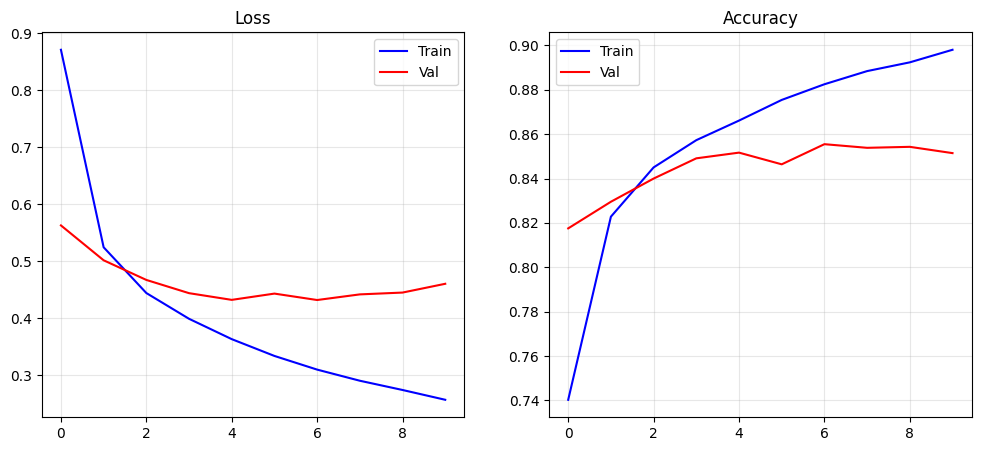

In [63]:
current_dir = os.getcwd()

artifacts_path = os.path.join(current_dir, 'artifacts', 'figures')
os.makedirs(artifacts_path, exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(e4_hist['train_loss'], 'b-', label='Train')
ax1.plot(e4_hist['val_loss'], 'r-', label='Val')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(e4_hist['train_acc'], 'b-', label='Train')
ax2.plot(e4_hist['val_acc'], 'r-', label='Val')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

file_path = os.path.join(artifacts_path, 'curves_best.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()


In [64]:
best_model = MLP(
    input_size=28*28,
    hidden_sizes=[512, 256, 128],
    num_classes=47,
    dropout_rate=0.0,
    use_batchnorm=True
).to(device)

torch.save(e4_model.state_dict(), os.path.join("artifacts", "best_model.pt"))
best_model.eval()

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)

In [65]:
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)

results = {
    "E1 (Base)": {
        "val_acc": max(e1_hist['val_acc']),
        "val_loss": min(e1_hist['val_loss']),
        "epochs": len(e1_hist['val_acc'])
    },
    "E2 (Dropout p=0.3)": {
        "val_acc": max(e2_hist['val_acc']),
        "val_loss": min(e2_hist['val_loss']),
        "epochs": len(e2_hist['val_acc'])
    },
    "E3 (BatchNorm)": {
        "val_acc": max(e3_hist['val_acc']),
        "val_loss": min(e3_hist['val_loss']),
        "epochs": len(e3_hist['val_acc'])
    },
    "E4 (EarlyStopping)": {
        "val_acc": early_stopper.best_score,
        "val_loss": min(e4_hist['val_loss']),
        "epochs": len(e4_hist['val_acc'])
    }
}

final_results = pd.DataFrame({
    'Experiment': ['E1 (Base)', 'E2 (Dropout)', 'E3 (BatchNorm)', 'E4 (EarlyStopping)', 'Test (Final)'],
    'Val/Test Acc': [
        results['E1 (Base)']['val_acc'],
        results['E2 (Dropout p=0.3)']['val_acc'],
        results['E3 (BatchNorm)']['val_acc'],
        results['E4 (EarlyStopping)']['val_acc'],
        test_acc
    ],
    'Val/Test Loss': [
        results['E1 (Base)']['val_loss'],
        results['E2 (Dropout p=0.3)']['val_loss'],
        results['E3 (BatchNorm)']['val_loss'],
        results['E4 (EarlyStopping)']['val_loss'],
        test_loss
    ]
})
display(final_results)

,Experiment,Val/Test Acc,Val/Test Loss
0,E1 (Base),0.666076,1.210003
1,E2 (Dropout),0.634649,1.313103
2,E3 (BatchNorm),0.857782,0.433080
3,E4 (EarlyStopping),0.855480,0.432033
4,Test (Final),0.023420,3.872612


In [66]:
os.makedirs('artifacts', exist_ok=True)

# Конфигурация лучшей модели (E4)
best_config = {
    "dataset": "EMNIST balanced",
    "seed": SEED,
    "input_dim": 28 * 28,
    "hidden_dims": [512, 256, 128],
    "num_classes": 47,
    "activation": "relu",
    "dropout_rate": 0.0,
    "use_batchnorm": True,
    "optimizer": "adam",
    "lr": 1e-3,
    "weight_decay": 0.0,
    "early_stopping_patience": 5,
    "epochs_trained": len(e4_hist['val_acc']),
    "best_val_accuracy": float(early_stopper.best_score),
    "best_val_loss": float(min(e4_hist['val_loss'])),
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss)
}

with open(os.path.join('artifacts', 'best_config.json'), 'w') as f:
    json.dump(best_config, f, indent=2)

Оптимизаторы

In [67]:
OPT_EPOCHS = 6

# Вспомогательная функция для создания модели эксперимента
def create_test_model():
    return MLP(
        input_size=28*28,
        hidden_sizes=[512, 256, 128],
        num_classes=47,
        dropout_rate=0.0,
        use_batchnorm=True
    ).to(device)

Большой L

In [68]:
model_o1 = create_test_model()
optimizer_o1 = make_optimizer(model_o1, kind="adam", lr=5e-1, weight_decay=0.0)
history_o1 = fit(model_o1, train_loader, val_loader, optimizer_o1, 
                 criterion, epochs=OPT_EPOCHS, verbose=True)

  Batch [200/1410], Loss: 3.9337, Acc: 0.0000
  Batch [400/1410], Loss: 3.9233, Acc: 0.0312
  Batch [600/1410], Loss: 3.9250, Acc: 0.0156
  Batch [800/1410], Loss: 4.0198, Acc: 0.0156
  Batch [1000/1410], Loss: 3.9547, Acc: 0.0469
  Batch [1200/1410], Loss: 3.9934, Acc: 0.0000
  Batch [1400/1410], Loss: 3.8763, Acc: 0.0625
Epoch 01/6 | train loss 3.9779, acc 0.021 | val loss 3.9246, acc 0.021 | 23.8s
  Batch [200/1410], Loss: 3.9437, Acc: 0.0469
  Batch [400/1410], Loss: 4.0182, Acc: 0.0000
  Batch [600/1410], Loss: 3.8856, Acc: 0.0312
  Batch [800/1410], Loss: 3.9920, Acc: 0.0156
  Batch [1000/1410], Loss: 3.9795, Acc: 0.0469
  Batch [1200/1410], Loss: 3.8759, Acc: 0.0156
  Batch [1400/1410], Loss: 3.8478, Acc: 0.0000
Epoch 02/6 | train loss 3.9458, acc 0.022 | val loss 3.9497, acc 0.022 | 23.5s
  Batch [200/1410], Loss: 4.0673, Acc: 0.0312
  Batch [400/1410], Loss: 3.8656, Acc: 0.0625
  Batch [600/1410], Loss: 4.0432, Acc: 0.0156
  Batch [800/1410], Loss: 4.0243, Acc: 0.0156
  Batch 

Маленький L

In [69]:
model_o2 = create_test_model()
optimizer_o2 = make_optimizer(model_o2, kind="adam", lr=1e-5, weight_decay=0.0)
history_o2 = fit(model_o2, train_loader, val_loader, optimizer_o2, 
                 criterion, epochs=OPT_EPOCHS, verbose=True)

  Batch [200/1410], Loss: 3.9285, Acc: 0.0156
  Batch [400/1410], Loss: 3.5411, Acc: 0.0938
  Batch [600/1410], Loss: 3.3506, Acc: 0.2031
  Batch [800/1410], Loss: 2.9792, Acc: 0.3750
  Batch [1000/1410], Loss: 2.8948, Acc: 0.2812
  Batch [1200/1410], Loss: 2.9711, Acc: 0.2500
  Batch [1400/1410], Loss: 2.5536, Acc: 0.4062
Epoch 01/6 | train loss 3.2536, acc 0.209 | val loss 2.6234, acc 0.403 | 23.3s
  Batch [200/1410], Loss: 2.5164, Acc: 0.5000
  Batch [400/1410], Loss: 2.5909, Acc: 0.3906
  Batch [600/1410], Loss: 2.3062, Acc: 0.5000
  Batch [800/1410], Loss: 2.1199, Acc: 0.5312
  Batch [1000/1410], Loss: 2.2921, Acc: 0.4688
  Batch [1200/1410], Loss: 2.2105, Acc: 0.4531
  Batch [1400/1410], Loss: 2.1886, Acc: 0.4844
Epoch 02/6 | train loss 2.3382, acc 0.481 | val loss 2.0625, acc 0.550 | 23.1s
  Batch [200/1410], Loss: 1.9347, Acc: 0.6406
  Batch [400/1410], Loss: 2.2294, Acc: 0.4531
  Batch [600/1410], Loss: 1.8652, Acc: 0.6562
  Batch [800/1410], Loss: 2.0022, Acc: 0.5781
  Batch 

SGD + momentum + weight decay

In [70]:
model_o3 = create_test_model()
optimizer_o3 = torch.optim.SGD(
    model_o3.parameters(),
    lr=2e-3,
    momentum=0.9,
    weight_decay=1e-4
)
history_o3 = fit(model_o3, train_loader, val_loader, optimizer_o3, 
                 criterion, epochs=12, verbose=True)

  Batch [200/1410], Loss: 2.0505, Acc: 0.5312
  Batch [400/1410], Loss: 1.6160, Acc: 0.5938
  Batch [600/1410], Loss: 1.4597, Acc: 0.6875
  Batch [800/1410], Loss: 1.0307, Acc: 0.7500
  Batch [1000/1410], Loss: 1.0424, Acc: 0.7188
  Batch [1200/1410], Loss: 0.8402, Acc: 0.7656
  Batch [1400/1410], Loss: 1.0865, Acc: 0.6875
Epoch 01/12 | train loss 1.4472, acc 0.631 | val loss 0.8462, acc 0.756 | 23.0s
  Batch [200/1410], Loss: 0.9633, Acc: 0.7188
  Batch [400/1410], Loss: 0.8077, Acc: 0.7344
  Batch [600/1410], Loss: 0.6138, Acc: 0.8906
  Batch [800/1410], Loss: 0.8271, Acc: 0.7188
  Batch [1000/1410], Loss: 0.6947, Acc: 0.8125
  Batch [1200/1410], Loss: 0.8438, Acc: 0.7188
  Batch [1400/1410], Loss: 0.7436, Acc: 0.8281
Epoch 02/12 | train loss 0.7407, acc 0.778 | val loss 0.6510, acc 0.798 | 22.6s
  Batch [200/1410], Loss: 0.6942, Acc: 0.7812
  Batch [400/1410], Loss: 0.5809, Acc: 0.7969
  Batch [600/1410], Loss: 0.5352, Acc: 0.8125
  Batch [800/1410], Loss: 0.6410, Acc: 0.7656
  Batc

График со сравнениями

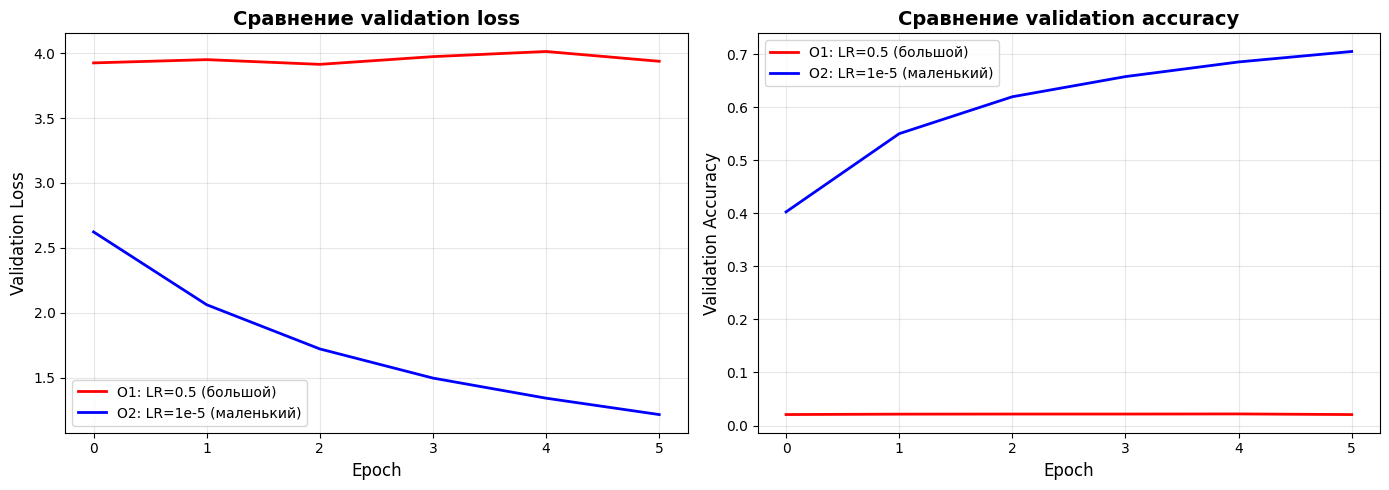

In [71]:
os.makedirs('figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_o1['val_loss'], 'r-', label='O1: LR=0.5 (большой)', linewidth=2)
axes[0].plot(history_o2['val_loss'], 'b-', label='O2: LR=1e-5 (маленький)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Loss', fontsize=12)
axes[0].set_title('Сравнение validation loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_o1['val_acc'], 'r-', label='O1: LR=0.5 (большой)', linewidth=2)
axes[1].plot(history_o2['val_acc'], 'b-', label='O2: LR=1e-5 (маленький)', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1].set_title('Сравнение validation accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=300, bbox_inches='tight')
plt.show()

In [72]:
def get_best_metrics(hist):
    best_acc = max(hist['val_acc'])
    best_acc_idx = hist['val_acc'].index(best_acc)
    best_loss_at_best_acc = hist['val_loss'][best_acc_idx]
    
    return best_acc, best_loss_at_best_acc, len(hist['val_acc'])

# Сбор данных по экспериментам
runs_data = []

# E1: Base
acc, loss, epochs = get_best_metrics(e1_hist)
runs_data.append({
    'experiment_id': 'E1',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=False',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})

# E2: Dropout
acc, loss, epochs = get_best_metrics(e2_hist)
runs_data.append({
    'experiment_id': 'E2',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.3, bn=False',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})

# E3: BatchNorm
acc, loss, epochs = get_best_metrics(e3_hist)
runs_data.append({
    'experiment_id': 'E3',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=True',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})

# E4: EarlyStopping
acc, loss, epochs = get_best_metrics(e4_hist)
runs_data.append({
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=False, early_stop(pat=5)',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': early_stopper.best_score,
    'best_val_loss': min(e4_hist['val_loss'])
})

# O1: LR слишком большой
acc, loss, epochs = get_best_metrics(history_o1)
runs_data.append({
    'experiment_id': 'O1',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=False',
    'optimizer': 'Adam',
    'lr': 5e-1,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})

# O2: LR слишком маленький
acc, loss, epochs = get_best_metrics(history_o2)
runs_data.append({
    'experiment_id': 'O2',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=False',
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})


# O3: SGD + Momentum + Weight Decay
acc, loss, epochs = get_best_metrics(history_o3)
runs_data.append({
    'experiment_id': 'O3',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=False',
    'optimizer': 'SGD',
    'lr': 2e-3,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})

df_runs = pd.DataFrame(runs_data)

df_runs.to_csv('artifacts/runs.csv', index=False)